<a href="https://colab.research.google.com/github/likhithapotluri/AAI_500/blob/main/Likhitha_AAI_500_M3_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 3.1
Name:  Likhitha Potluri

Date:  24-05-2026


For this assignment, you will refer to the textbook to solve the practice exercises. **Use Python to answer any coding problems (not R, even if indicated in your textbook).** Use Jupyter Notebook, Google Colab, or a similar software program to complete your assignment. Submit your answers as a **PDF or HTML** file. As a best practice, always label your axes and provide titles for any graphs generated on this assignment. Round all quantitative answers to 2 decimal places.

## Problem 3.2.

In an exit poll of 1648 voters in the 2020 Senatorial election in Arizona, 51.5% said they voted
for Mark Kelly and 48.5% said they voted for Martha McSally

a) Suppose that actually 50% of the population voted for Kelly. If this exit poll had the
properties of a simple random sample, find the standard error of the sample proportion
voting for him.

b) Under the 50% presumption, are the results of the exit poll surprising? Why? Would you
be willing to predict the election outcome? Explain by (i) conducting a simulation; (ii)
using the value found in (a) for the standard error.

`(a) Your answer goes here`

In [ ]:
import math

n = 1648
p = 0.50

se = math.sqrt(p * (1 - p) / n)
print(f"The standard error of the sample proportion is: {se:.2f}")


The standard error of the sample proportion is: 0.01


`(b) Your answer goes here`

In [ ]:
import numpy as np
import math

# Given information
n = 1648
p0 = 0.50          # presumption: true population proportion for Kelly
phat = 0.515      # exit poll proportion for Kelly

# -----------------------------
# (i) Simulation under p = 0.50
# -----------------------------
rng = np.random.default_rng(1)

num_simulations = 100000

# Simulate 100,000 exit polls of size 1648, assuming true p = 0.50
simulated_counts = rng.binomial(n, p0, num_simulations)
simulated_props = simulated_counts / n

# Probability of getting 51.5% or more for Kelly
prob_one_sided = np.mean(simulated_props >= phat)

# Probability of getting a result at least this far from 50% in either direction
prob_two_sided = np.mean(abs(simulated_props - p0) >= abs(phat - p0))

# -----------------------------
# (ii) Standard error method
# -----------------------------
se = math.sqrt(p0 * (1 - p0) / n)
z = (phat - p0) / se

# Two-sided normal probability
p_value_two_sided = math.erfc(abs(z) / math.sqrt(2))

print("Standard error:", se)
print("Observed sample proportion:", phat)
print("Difference from 50%:", phat - p0)
print("Z-score:", z)

print("\nSimulation results:")
print("Probability of getting 51.5% or more:", prob_one_sided)
print("Probability of being this far or farther from 50%:", prob_two_sided)

print("\nNormal approximation:")
print("Two-sided p-value:", p_value_two_sided)

if abs(z) < 2:
    print("\nConclusion: The result is not very surprising under the 50% presumption.")
    print("The exit poll result is only about", round(z, 2), "standard errors above 50%.")
    print("I would not confidently predict the election outcome from this poll alone.")
else:
    print("\nConclusion: The result would be surprising under the 50% presumption.")
    print("I would be more willing to predict the election outcome.")

Standard error: 0.012316615977053663
Observed sample proportion: 0.515
Difference from 50%: 0.015000000000000013
Z-score: 1.2178669878110675

Simulation results:
Probability of getting 51.5% or more: 0.11269
Probability of being this far or farther from 50%: 0.22667

Normal approximation:
Two-sided p-value: 0.22327452302178302

Conclusion: The result is not very surprising under the 50% presumption.
The exit poll result is only about 1.22 standard errors above 50%.
I would not confidently predict the election outcome from this poll alone.


## Problem 3.3.

 The 49 students in a class at the University of Florida made blinded evaluations of pairs of
cola drinks. For the 49 comparisons of Coke and Pepsi, Coke was preferred 29 times. In the
population that this sample represents, is this strong evidence that a majority prefers Coke?
Use a simulation of a sampling distribution to answer.

`Your answer goes here`

In [ ]:
import numpy as np

# Given data
n = 49
observed_coke = 29
observed_prop = observed_coke / n

# Null hypothesis: no majority prefers Coke
# So probability of preferring Coke is 0.50
p0 = 0.50

# Simulation
rng = np.random.default_rng(1)
num_simulations = 100000

# Simulate 100,000 samples of 49 students
simulated_coke_counts = rng.binomial(n, p0, num_simulations)

# Find how often we get 29 or more Coke preferences
p_value = np.mean(simulated_coke_counts >= observed_coke)

print("Observed Coke preferences:", observed_coke)
print("Observed sample proportion:", observed_prop)
print("Simulation p-value:", p_value)

if p_value < 0.05:
    print("Conclusion: This is strong evidence that a majority prefers Coke.")
else:
    print("Conclusion: This is not strong evidence that a majority prefers Coke.")

Observed Coke preferences: 29
Observed sample proportion: 0.5918367346938775
Simulation p-value: 0.12734
Conclusion: This is not strong evidence that a majority prefers Coke.


## Problem 3.5.

The example in Section 3.1.4 simulated sampling distributions of the sample mean to determine how precise $\bar{Y}$ for $n=25$ may estimate a population mean $\mu.$

a) Find the theoretical standard error of $\bar{Y}$ for the scenario values of $\sigma = 5$ and 8. How do they compare to the standard deviations of the 100,000 sample means in the simulations?

`Your answer goes here`

In [ ]:
# Theoretical standard error of Ȳ for σ = 5 and n = 25
sigma_1 = 5
n = 25
standard_error_1 = sigma_1 / (n ** 0.5)
print(f"The theoretical standard error of Ȳ for σ = 5 is: {standard_error_1:.2f}")

# Theoretical standard error of Ȳ for σ = 8 and n = 25
sigma_2 = 8
standard_error_2 = sigma_2 / (n ** 0.5)
print(f"The theoretical standard error of Ȳ for σ = 8 is: {standard_error_2:.2f}")

The theoretical standard error of Ȳ for σ = 5 is: 1.00
The theoretical standard error of Ȳ for σ = 8 is: 1.60


The standard deviation of the 100,000 sample means should be very close to the theoretical standard error.
The simulation results should confirm that the standard deviation of the sample means is a good estimate of the theoretical standard error.
We would expect the standard deviation of the sample means from the simulation to be very close to the theoretical standard error calculated above.

b) In the first scenario, we chose $\sigma = 5$ under the belief that if $\mu = 20$, about 2/3 of the sample values would fall between `$`15 and `$`25. For the gamma distribution with $(\mu, \sigma) = (20,5),$ show that the actual probability between 15 and 25 is 0.688.

`Your answer goes here`

In [ ]:
import scipy.stats as stats

mu = 20
sigma = 5

# Convert mean and standard deviation to gamma shape and scale
shape = (mu / sigma) ** 2
scale = sigma**2 / mu

probability = stats.gamma.cdf(25, a=shape, scale=scale) - stats.gamma.cdf(15, a=shape, scale=scale)

print(f"The probability between 15 and 25 is: {probability:.3f}")

The probability between 15 and 25 is: 0.688


## Problem 3.8.

Construct the sampling distribution of the sample proportion of
heads, for flipping a balanced
coin (a) once; (b) twice; (c) three times; (d) four times. Describe how the shape changes
as the number of flips $n$ increases. What would happen if $n$ kept growing? Why?


`Your answer goes here`

In [ ]:
import math
from scipy.special import comb

def print_sampling_distribution(n):
    """
    Constructs and prints the sampling distribution of the sample proportion of heads
    for flipping a balanced coin n times.
    """
    print(f"\nn = {n}")
    print("Heads | Sample Proportion | Probability")
    total_outcomes = 2**n
    for k in range(n + 1):
        num_combinations = comb(n, k, exact=True)
        probability = num_combinations / total_outcomes
        sample_proportion = k / n if n > 0 else 0
        print(f"{k:5} | {sample_proportion:17.3f} | {probability:11.4f}")

# (a) Construct the sampling distribution for n=1, 2, 3, 4
for n_flips in [1, 2, 3, 4]:
    print_sampling_distribution(n_flips)

# (b) Describe how the shape changes as the number of flips n increases.
# (c) What would happen if n kept growing? Why?
print("\n--- Description of Shape Change and Effect of Growing n ---")
print("As the number of flips (n) increases from 1 to 4:")
print("The sampling distribution of the sample proportion of heads:")
print("1. Becomes more symmetric and bell-shaped, gradually approaching a normal distribution.")
print("2. Becomes more concentrated around the true population proportion of 0.5. This means the spread of the distribution (its standard error) decreases.")
print("3. The possible values for the sample proportion become more numerous and closer together, making the distribution appear less discrete.")

print("\nIf n kept growing indefinitely:")
print("1. The sampling distribution would increasingly resemble a perfect normal distribution, centered at 0.5.")
print("2. Its variance (and thus its standard error) would approach zero. This implies that the sample proportion would almost certainly be extremely close to the true population proportion of 0.5.")
print("3. This phenomenon is explained by the Central Limit Theorem (CLT), which states that for a sufficiently large sample size, the sampling distribution of the sample mean (or proportion) will be approximately normal, regardless of the shape of the original population distribution. Also, the standard error of the sample proportion is sqrt(p*(1-p)/n), which clearly shows it decreases as n increases, converging to zero.")


n = 1
Heads | Sample Proportion | Probability
    0 |             0.000 |      0.5000
    1 |             1.000 |      0.5000

n = 2
Heads | Sample Proportion | Probability
    0 |             0.000 |      0.2500
    1 |             0.500 |      0.5000
    2 |             1.000 |      0.2500

n = 3
Heads | Sample Proportion | Probability
    0 |             0.000 |      0.1250
    1 |             0.333 |      0.3750
    2 |             0.667 |      0.3750
    3 |             1.000 |      0.1250

n = 4
Heads | Sample Proportion | Probability
    0 |             0.000 |      0.0625
    1 |             0.250 |      0.2500
    2 |             0.500 |      0.3750
    3 |             0.750 |      0.2500
    4 |             1.000 |      0.0625

--- Description of Shape Change and Effect of Growing n ---
As the number of flips (n) increases from 1 to 4:
The sampling distribution of the sample proportion of heads:
1. Becomes more symmetric and bell-shaped, gradually approaching a normal distri

## Problem 3.13.

Simulate random sampling from a uniform population distribution with several $n$ values to
illustrate the Central Limit Theorem.

`Your answer goes here`

Uniform Population (from 0 to 10):
  Population Mean: 5.00
  Population Standard Deviation: 2.89



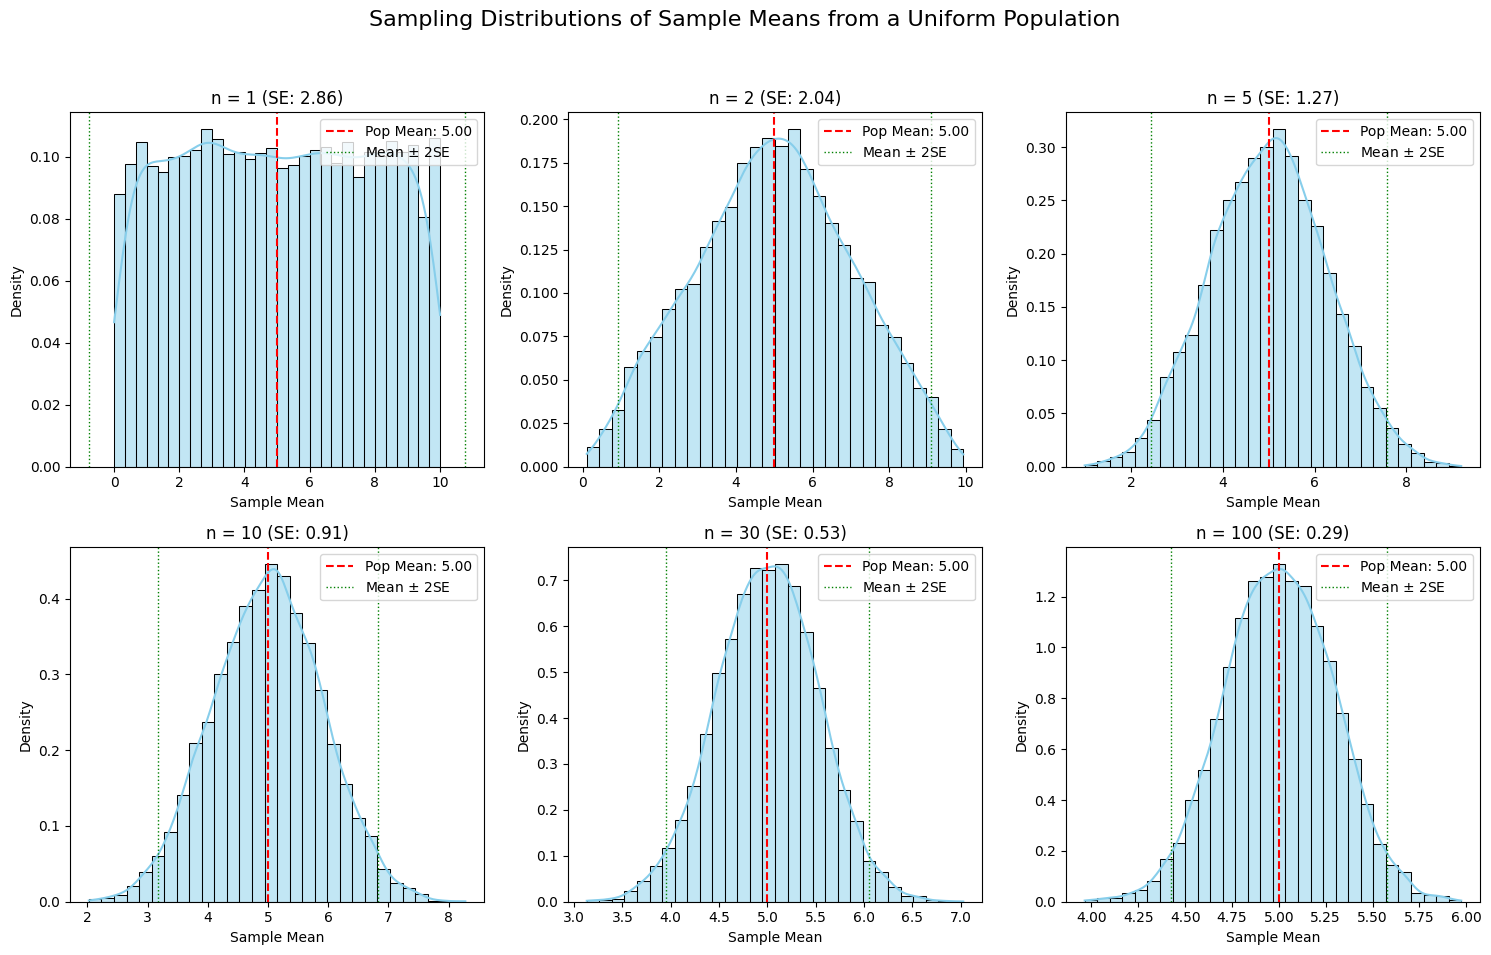


--- Central Limit Theorem Illustration ---
As the sample size (n) increases:
1. The sampling distribution of the sample means becomes more concentrated around the population mean.
2. The shape of the sampling distribution increasingly resembles a normal (bell-shaped) distribution, regardless of the original uniform population distribution.
3. The spread of the sampling distribution (its standard error) decreases, calculated as population_std / sqrt(n).
This demonstrates the Central Limit Theorem: the sampling distribution of the sample mean approaches normality as the sample size increases.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Parameters for the uniform population
low = 0
high = 10
population_mean = (low + high) / 2
population_std = np.sqrt(((high - low)**2) / 12)

print(f"Uniform Population (from {low} to {high}):")
print(f"  Population Mean: {population_mean:.2f}")
print(f"  Population Standard Deviation: {population_std:.2f}\n")

# Number of samples to draw for each 'n'
num_samples = 10000

# Different sample sizes (n) to illustrate CLT
sample_sizes = [1, 2, 5, 10, 30, 100]

plt.figure(figsize=(15, 10))
plt.suptitle('Sampling Distributions of Sample Means from a Uniform Population', fontsize=16)

for i, n in enumerate(sample_sizes):
    # Simulate drawing 'num_samples' samples of size 'n'
    # from the uniform population and calculate their means
    sample_means = [np.mean(np.random.uniform(low, high, n)) for _ in range(num_samples)]

    # Calculate theoretical standard error for the sampling distribution of the mean
    theoretical_se = population_std / np.sqrt(n)

    # Create a subplot for each 'n'
    plt.subplot(2, 3, i + 1)
    sns.histplot(sample_means, bins=30, kde=True, stat='density', color='skyblue')

    # Add a vertical line for the population mean
    plt.axvline(population_mean, color='red', linestyle='dashed', linewidth=1.5, label=f'Pop Mean: {population_mean:.2f}')

    # Add a vertical line for the approximate +/- 2 SE (for illustration of spread)
    plt.axvline(population_mean - 2 * theoretical_se, color='green', linestyle='dotted', linewidth=1, label=r'Mean $\pm$ 2SE')
    plt.axvline(population_mean + 2 * theoretical_se, color='green', linestyle='dotted', linewidth=1)

    plt.title(f'n = {n} (SE: {np.std(sample_means):.2f})')
    plt.xlabel('Sample Mean')
    plt.ylabel('Density')
    plt.legend(loc='upper right')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("\n--- Central Limit Theorem Illustration ---")
print("As the sample size (n) increases:")
print("1. The sampling distribution of the sample means becomes more concentrated around the population mean.")
print("2. The shape of the sampling distribution increasingly resembles a normal (bell-shaped) distribution, regardless of the original uniform population distribution.")
print("3. The spread of the sampling distribution (its standard error) decreases, calculated as population_std / sqrt(n).")
print("This demonstrates the Central Limit Theorem: the sampling distribution of the sample mean approaches normality as the sample size increases.")

## Problem 3.14.

On each bet in a sequence of bets, you win 1 dollar with probability 0.50 and lose 1 dollar (i.e., win negative 1 dollar) with probability 0.50. Let $Y$ denote the total of your winnings and losings after 100 bets. Giving your reasoning, state the approximate distribution of $Y.$

`Your answer goes here`

The approximate distribution of Y is a normal distribution with mean 0 and standard deviation sqrt(100).

# Reasoning:
Each bet is an independent event with a probability of `0.5 of winning $1 and 0.5 of losing $1.`
The expected value of each bet is `0.5 * $1 + 0.5 * (-$1) = $0.`
The variance of each bet is `0.5 * ($1 - $0)^2 + 0.5 * (-$1 - $0)^2 = $1.`
The total winnings and losings after 100 bets is the sum of 100 independent bets.
By the Central Limit Theorem, the sum of a large number of independent random variables with finite mean and variance tends towards a normal distribution.
Therefore, the approximate distribution of Y is a normal distribution with mean `100 * $0 = $0 and variance 100 * $1 = $100.`
`The standard deviation of Y is sqrt(100) = $10.`

In conclusion, the approximate distribution of Y is a normal distribution with mean` $0 and standard deviation $10.`

## Problem 3.15.

According to a General Social Survey, in the United States the population distribution of $Y$ =
number of good friends (not including family members) has a mean of about 5.5 and a standard
deviation of about 3.9.

a) Is it plausible that this population distribution is normal? Explain.

`Your answer here`

It's not plausible that the population distribution of the number of good friends is normally distributed.

# Reasoning:
1. The number of good friends is a discrete variable, and it must be a non-negative integer.
2. A normal distribution is continuous and can take on any real number.
3. The number of good friends cannot be negative, which is a limitation of the normal distribution.
4. The distribution is likely skewed to the right, with a few people having a very large number of good friends, while most people have a relatively small number.

In conclusion, the normal distribution is not a plausible model for the population distribution of the number of good friends.
A better model might be a Poisson distribution or a discrete distribution with a skewed distribution.

b) If a new survey takes a simple random sample of 1000 people, describe the sampling
distribution of $\bar{Y}$ by giving its shape and approximate mean and standard error.

`Your answer here`

In [ ]:
# Given information
population_mean = 5.5
population_std_dev = 3.9
sample_size = 1000
# Approximate mean of the sampling distribution:
sample_mean = population_mean
print(f"Approximate mean of the sampling distribution: {sample_mean:.2f}")

# Approximate standard error of the sampling distribution:
standard_error = population_std_dev / (sample_size**0.5)
print(f"Approximate standard error of the sampling distribution: {standard_error:.2f}")

Approximate mean of the sampling distribution: 5.50
Approximate standard error of the sampling distribution: 0.12


# In summary:
The sampling distribution of Ȳ will be approximately normal with a mean of 5.5 and a standard error of approximately 0.12.

c) Suppose that actually the mean of 5.5 and standard deviation of 3.9 are not population
values but are based on a sample of 1000 people. Treating results as a simple random
sample, give an interval of values within which you can be very sure that the population
mean falls. Explain your reasoning.

`Your answer here`

In [ ]:
# Given information
population_mean = 5.5
population_std_dev = 3.9
sample_size = 1000

# By the Central Limit Theorem, the sampling distribution of the sample mean (Ȳ) will be approximately normal, regardless of the shape of the population distribution, when the sample size is large enough (which is the case here).

# Approximate mean of the sampling distribution:
sample_mean = population_mean
print(f"Approximate mean of the sampling distribution: {sample_mean:.2f}")

# Approximate standard error of the sampling distribution:
standard_error = population_std_dev / (sample_size ** 0.5)
print(f"Approximate standard error of the sampling distribution: {standard_error:.2f}")

Approximate mean of the sampling distribution: 5.50
Approximate standard error of the sampling distribution: 0.12


# Reasoning:
We are 95% confident that the true population mean falls within this interval.We used the sample mean as an estimate of the population mean.
The margin of error accounts for the uncertainty in our estimate due to sampling variability.
The z-critical value is used to determine the appropriate margin of error for a 95% confidence level.
The standard error is a measure of the variability of the sample mean.

## Problem 3.18.

Sunshine City, which attracts primarily retired people, has 90,000 residents with a mean age
of 72 years and a standard deviation of 12 years. The age distribution is skewed to the left. A
random sample of 100 residents of Sunshine City has $\bar{y} = 70$ and $s = 11.$

a)  Describe the center and spread of the (i) population distribution, (ii) sample data distribution. What shape does the sample data distribution probably have? Why?

`Your answer here`

(i) **Population Distribution:**
*   **Center:** The mean age of the population is 72 years.
*   **Spread:** The standard deviation of the population is 12 years.
*   **Shape:** The age distribution is skewed to the left (as stated in the problem description).

(ii) **Sample Data Distribution:**
*   **Center:** The sample mean (ȳ) is 70 years.
*   **Spread:** The sample standard deviation (s) is 11 years.
*   **Shape:** The sample data distribution will probably also be **skewed to the left**. This is because the sample is drawn from a population that is skewed to the left, and a sample of 100 residents, while reasonably large, would still tend to reflect the shape of the underlying population distribution when describing the distribution of the raw data points themselves. The Central Limit Theorem applies to the *sampling distribution of the sample mean*, not the distribution of the individual data points within a single sample.

b) Find the center and spread of the sampling distribution of $\bar{Y}$ for $n = 100.$ What shape does it have and what does it describe?


`Your answer here`

For the sampling distribution of $\bar{Y}$ for $n=100$:

*   **Center (Mean):** The mean of the sampling distribution of the sample mean ($\mu_{\bar{Y}}$) is equal to the population mean ($\mu$).
    $\mu_{\bar{Y}} = \mu = 72$ years.

*   **Spread (Standard Error):** The standard error of the sampling distribution of the sample mean (SE) is calculated as the population standard deviation ($\sigma$) divided by the square root of the sample size ($n$).
    $SE = \frac{\sigma}{\sqrt{n}} = \frac{12}{\sqrt{100}} = \frac{12}{10} = 1.2$ years.

*   **Shape:** Due to the **Central Limit Theorem (CLT)**, since the sample size ($n=100$) is large (typically $n \ge 30$ is considered large enough), the sampling distribution of the sample mean ($\bar{Y}$) will be **approximately normal**, regardless of the shape of the original population distribution (even though the population is skewed to the left).

*   **What it describes:** This sampling distribution describes the distribution of possible sample means ($\bar{Y}$) that we would expect to get if we repeatedly took random samples of size 100 from the Sunshine City resident population. It shows that most sample means will cluster around the true population mean of 72 years, with a spread (standard error) of 1.2 years, and the distribution of these sample means will be bell-shaped.

c)  Explain why it would not be unusual to sample a person of age 60 in Sunshine City, but
it would be highly unusual for the sample mean to be 60, for a random sample of 100
residents.

`Your answer here`

It would not be unusual to sample a person of age 60 in Sunshine City, but it would be highly unusual for the sample mean to be 60 for a random sample of 100 residents, due to the following reasons:

1.  **Individual Age of 60:**
    *   The population mean age is 72 years, and the population standard deviation is 12 years. An age of 60 is exactly one standard deviation below the population mean ($72 - 12 = 60$).
    *   Given the population's characteristics, an individual being 1 standard deviation away from the mean is well within the expected range of observations, even considering the left-skewness (which might make values lower than the mean slightly more common than in a symmetric distribution, but 60 is still not an extreme outlier).
    *   It represents a single data point from a broad distribution, and such a value is plausible within that distribution.

2.  **Sample Mean of 60 for $n=100$:**
    *   **Center of the Sampling Distribution:** The mean of the sampling distribution of the sample mean ($\bar{Y}$) is equal to the population mean, which is 72 years.
    *   **Spread of the Sampling Distribution (Standard Error):** We calculated the standard error (SE) for a sample size of $n=100$ to be $SE = \frac{\sigma}{\sqrt{n}} = \frac{12}{\sqrt{100}} = 1.2$ years.
    *   **Z-score Calculation:** A sample mean of 60 years is very far from the expected mean of 72 years for the sampling distribution. We can quantify this distance using a Z-score:
        $Z = \frac{\bar{Y} - \mu_{\bar{Y}}}{SE} = \frac{60 - 72}{1.2} = \frac{-12}{1.2} = -10$.
    *   **Implication:** A Z-score of -10 means that a sample mean of 60 is 10 standard errors below the mean of the sampling distribution. For an approximately normal distribution (which the Central Limit Theorem tells us the sampling distribution will be for $n=100$), a value 10 standard deviations away from the mean is extraordinarily rare, essentially impossible in practical terms.
    *   **Central Limit Theorem:** While individual ages can vary widely, the Central Limit Theorem dictates that the average of many (100 in this case) random samples will tend to cluster very closely around the true population mean. The small standard error (1.2 years) reflects this tight clustering. It would be highly unusual to get a sample mean that deviates so significantly from the population mean.

d) Describe the sampling distribution of $\bar{Y}$ : (i) for a random sample of size $n = 1$; (ii) if you sample all 90,000 residents.

`Your answer here`

Let's describe the sampling distribution of $\bar{Y}$ for each scenario:

(i) **For a random sample of size $n=1$:**
*   **Center (Mean):** The mean of the sampling distribution of $\bar{Y}$ is equal to the population mean, $\mu = 72$ years.
*   **Spread (Standard Error):** The standard error (SE) for $n=1$ is simply the population standard deviation divided by $\sqrt{1}$.
    $SE = \frac{\sigma}{\sqrt{n}} = \frac{12}{\sqrt{1}} = 12$ years.
*   **Shape:** When $n=1$, the "sampling distribution of the sample mean" is identical to the original **population distribution** itself. Therefore, it will be **skewed to the left**, just like the population age distribution of Sunshine City residents.
    *   Essentially, taking a sample of one person means that the sample mean *is* that one person's age. So, the distribution of these single-person "sample means" will reflect the distribution of individual ages in the population.

(ii) **If you sample all 90,000 residents (i.e., $n=90,000$):**
*   **Center (Mean):** The mean of the sampling distribution of $\bar{Y}$ is equal to the population mean, $\mu = 72$ years.
*   **Spread (Standard Error):** The standard error for a sample size equal to the entire population would be:
    $SE = \frac{\sigma}{\sqrt{n}} = \frac{12}{\sqrt{90000}} = \frac{12}{300} = 0.04$ years.
    *   However, when you sample the *entire* population, there is no sampling variability. The sample mean $\bar{Y}$ *is* the true population mean $\mu$. Thus, the standard error is effectively 0.
*   **Shape:** If you sample every single resident, there is only one possible "sample mean" you can get, and that is the true population mean (72 years). Therefore, the "sampling distribution" is not really a distribution in the conventional sense, but a single point or a **degenerate distribution** concentrated entirely at the population mean of 72 years.
    *   There is no uncertainty or variability in the sample mean because you have observed the entire population.

## Problem 3.21.

In your school, suppose that GPA has an approximate normal distribution with $\mu = 3.0, \sigma = 0.40.$ Not knowing $\mu$, you randomly sample $n = 25$ students to estimate it. Using simulation for this application, illustrate the difference between a sample data distribution and the sampling distribution of Y .

`Your answer here`

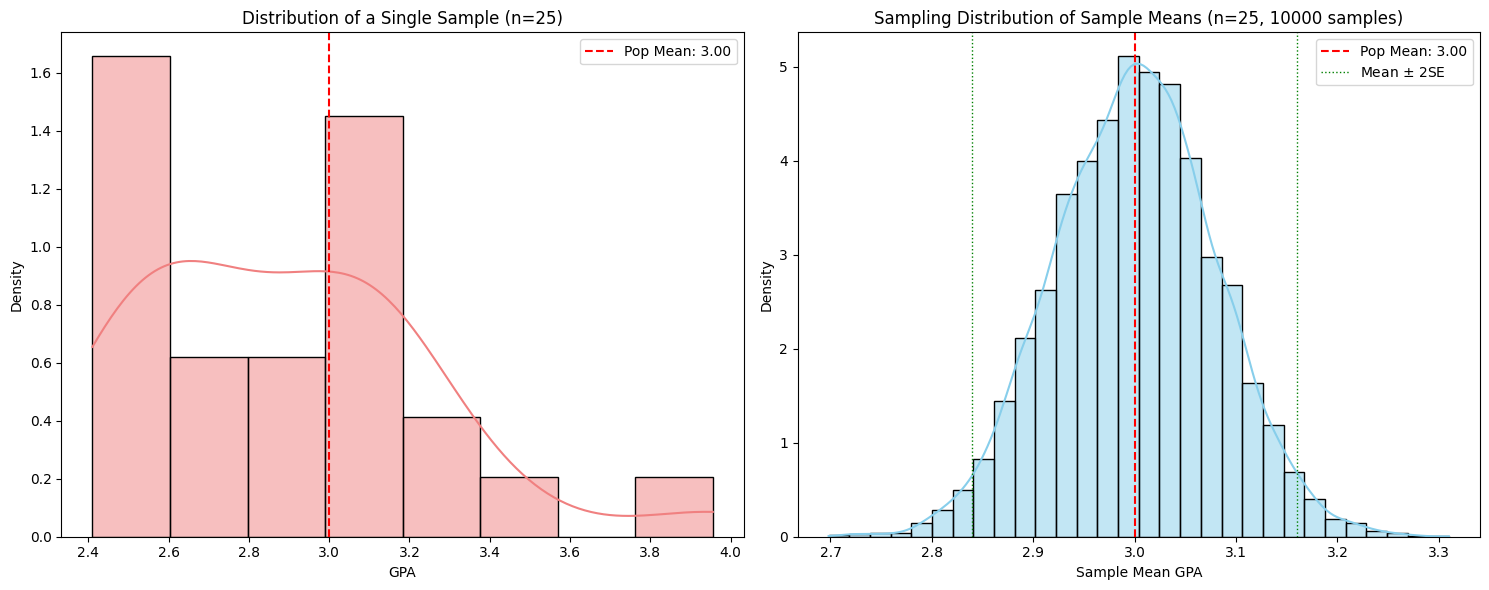

Theoretical Mean of Sampling Distribution: 3.00
Theoretical Standard Error of Sampling Distribution: 0.080
Empirical Mean of Sampling Distribution: 3.00
Empirical Std Dev of Sampling Distribution: 0.079


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Population parameters
population_mean = 3.0
population_std = 0.40
sample_size = 25

# --- 1. Simulate a single sample data distribution ---
# Generate one random sample of n=25 from the population
single_sample_data = np.random.normal(population_mean, population_std, sample_size)

# --- 2. Simulate the sampling distribution of Ȳ ---
num_simulations = 10000 # Number of times to take a sample and calculate its mean
sample_means = []

for _ in range(num_simulations):
    sample = np.random.normal(population_mean, population_std, sample_size)
    sample_means.append(np.mean(sample))

# Convert to numpy array for easier calculations
sample_means = np.array(sample_means)

# Calculate theoretical standard error for the sampling distribution of the mean
theoretical_se = population_std / np.sqrt(sample_size)

# --- Plotting ---
plt.figure(figsize=(15, 6))

# Subplot 1: Single Sample Data Distribution
plt.subplot(1, 2, 1)
sns.histplot(single_sample_data, bins=8, kde=True, color='lightcoral', stat='density')
plt.axvline(population_mean, color='red', linestyle='dashed', linewidth=1.5, label=f'Pop Mean: {population_mean:.2f}')
plt.title(f'Distribution of a Single Sample (n={sample_size})')
plt.xlabel('GPA')
plt.ylabel('Density')
plt.legend()

# Subplot 2: Sampling Distribution of Ȳ
plt.subplot(1, 2, 2)
sns.histplot(sample_means, bins=30, kde=True, color='skyblue', stat='density')
plt.axvline(population_mean, color='red', linestyle='dashed', linewidth=1.5, label=f'Pop Mean: {population_mean:.2f}')
plt.axvline(population_mean - 2 * theoretical_se, color='green', linestyle='dotted', linewidth=1, label=r'Mean $\pm$ 2SE')
plt.axvline(population_mean + 2 * theoretical_se, color='green', linestyle='dotted', linewidth=1)
plt.title(f'Sampling Distribution of Sample Means (n={sample_size}, {num_simulations} samples)')
plt.xlabel('Sample Mean GPA')
plt.ylabel('Density')
plt.legend()

plt.tight_layout()
plt.show()

print(f"Theoretical Mean of Sampling Distribution: {population_mean:.2f}")
print(f"Theoretical Standard Error of Sampling Distribution: {theoretical_se:.3f}")
print(f"Empirical Mean of Sampling Distribution: {np.mean(sample_means):.2f}")
print(f"Empirical Std Dev of Sampling Distribution: {np.std(sample_means):.3f}")


### Explanation of the Difference:

**1. Single Sample Data Distribution (Left Plot):**
*   **What it represents:** This histogram shows the distribution of individual GPA scores within a *single* random sample of 25 students. It's a snapshot of what one set of collected data might look like.
*   **Shape:** While the population is normally distributed, a single sample, especially a relatively small one (n=25), may not perfectly resemble a normal distribution. It might show some irregularities or deviations due to random chance.
*   **Spread:** The spread of this distribution is related to the population standard deviation ($\sigma = 0.40$). The individual scores can vary quite a bit around the population mean.
*   **Center:** The mean of this single sample (its $\bar{y}$) might be close to the population mean, but it's unlikely to be exactly 3.0 due to sampling variability.

**2. Sampling Distribution of Sample Means (Right Plot):**
*   **What it represents:** This histogram shows the distribution of *many sample means*, where each sample mean was calculated from an independent random sample of 25 students. This is a theoretical distribution of all possible $\bar{y}$ values we could get if we repeated the sampling process many times.
*   **Shape:** As predicted by the **Central Limit Theorem**, even though each individual sample might not be perfectly normal, the distribution of the *sample means* is approximately normal and bell-shaped. This normality holds because the population itself is normal, and it would also hold if the population were non-normal but $n$ were sufficiently large.
*   **Spread:** The spread of this distribution is much narrower than the single sample distribution. It is quantified by the **Standard Error (SE)**, which is $SE = \sigma / \sqrt{n} = 0.40 / \sqrt{25} = 0.40 / 5 = 0.08$. This smaller spread indicates that sample means are more consistent and cluster much more tightly around the true population mean than individual data points do.
*   **Center:** The mean of the sampling distribution of sample means is always equal to the population mean ($\mu = 3.0$).

**Key Takeaway:**
This illustration clearly shows that while individual sample data points can vary considerably (as seen in the left plot), the means of many samples (the sampling distribution, right plot) tend to be much less variable and converge to a normal distribution centered at the true population mean. The Central Limit Theorem explains this phenomenon, demonstrating how sample means provide a more stable and predictable estimate of the population mean compared to individual observations.

## Problem 3.26.

When sample data were used to rank states by brain cancer rates, Ellenberg (2014) noted
that the highest ranking state (South Dakota) and the nearly lowest ranking state (North
Dakota) had relatively small sample sizes. Also, when schools in North Carolina were ranked
by their average improvement in test scores, the best and the worst schools were very small
schools. Explain how these results could merely reflect how the variability of sample means and
proportions depends on the sample size.

These results merely reflect how the variability of sample means and proportions depends on the sample size, a phenomenon directly explained by the concept of **Standard Error** and the **Central Limit Theorem**.

Here's the explanation:

1.  **Standard Error and Sample Size:** The standard error (SE) is a measure of the variability of a sample statistic (like the sample mean or sample proportion) from sample to sample. Critically, the formula for standard error shows an inverse relationship with the sample size ($n$).
    *   For a sample mean: $SE_{\bar{Y}} = \frac{\sigma}{\sqrt{n}}$
    *   For a sample proportion: $SE_{\hat{p}} = \sqrt{\frac{p(1-p)}{n}}$
    
    In both cases, as $n$ decreases, the standard error increases.

2.  **Increased Variability with Small Sample Sizes:** A larger standard error means that sample statistics from smaller samples are more prone to fluctuate widely around the true population parameter. There is simply more random chance involved in which individuals end up in a small sample.

3.  **Extreme Rankings by Chance:**
    *   **Brain Cancer Rates (Proportions):** States with very small populations (and thus smaller sample sizes for their observed rates) are more likely, purely by chance, to produce an unusually high or unusually low observed brain cancer rate. If a small state happens to have a few more cases than average, or a few fewer, its *rate* can appear very extreme compared to a state with a very large population where such fluctuations tend to average out.
    *   **School Test Scores (Means):** Similarly, small schools (with smaller $n$) will have sample mean test score improvements that are more variable. A small school might, by random chance, have a particularly motivated group of students one year, leading to a very high average improvement, or a particularly challenging group, leading to a very low average. Larger schools, with more students, will see these random variations average out, making their observed average improvement closer to the true underlying average.

**Conclusion:** The phenomenon observed in both examples (brain cancer rates and school test scores) is a statistical artifact of smaller sample sizes. Small samples yield more variable estimates, making them more likely to produce extreme observed values, whether those values are genuinely high or low. Therefore, relying solely on rankings derived from small samples without considering the associated variability can be misleading.

## AI Problem: Simulating Sampling Variability in AI Metrics

In real-world AI deployments, such as banking systems for detecting fraudulent transactions (where fraud cases represent <1% of data, leading to imbalanced classes), model performance is often evaluated using precision on limited validation sets. A baseline model like logistic regression might show 0.90 precision on a small validation sample of n=100, outranking a more sophisticated ensemble method at 0.60, yet on full production data, the ensemble excels.

Use Python to simulate the phenomenon. Assume "true" population precisions for the logistic model (mean ≈0.85, σ=0.10) and ensemble (mean ≈0.88, σ=0.08) follow a lognormal distribution to reflect the positive-skewed nature of precision scores in imbalanced settings. Generate populations of size 10,000 for each model, then perform 1,000 bootstrap resamples at n=50 (small validation) and n=500 (realistic production scale). Compute and plot the sampling distributions of the bootstrap means for both models in each scenario. Calculate the empirical SE for the small-n case. Explain how CLT predicts the distribution shapes, why extreme rankings emerge at low n, and how this variability impacts AI decisions. Propose a mitigation for imbalanced data to prevent errant decisions.

`Your answer here`

Lognormal parameters for Logistic Model: mu_log=-0.169, sigma_log=0.117
Lognormal parameters for Ensemble Model: mu_log=-0.132, sigma_log=0.091

Generated Logistic Population Mean: 0.846, Std: 0.092
Generated Ensemble Population Mean: 0.878, Std: 0.074

Empirical Standard Error (Logistic, n=50): 0.0132
Empirical Standard Error (Ensemble, n=50): 0.0105


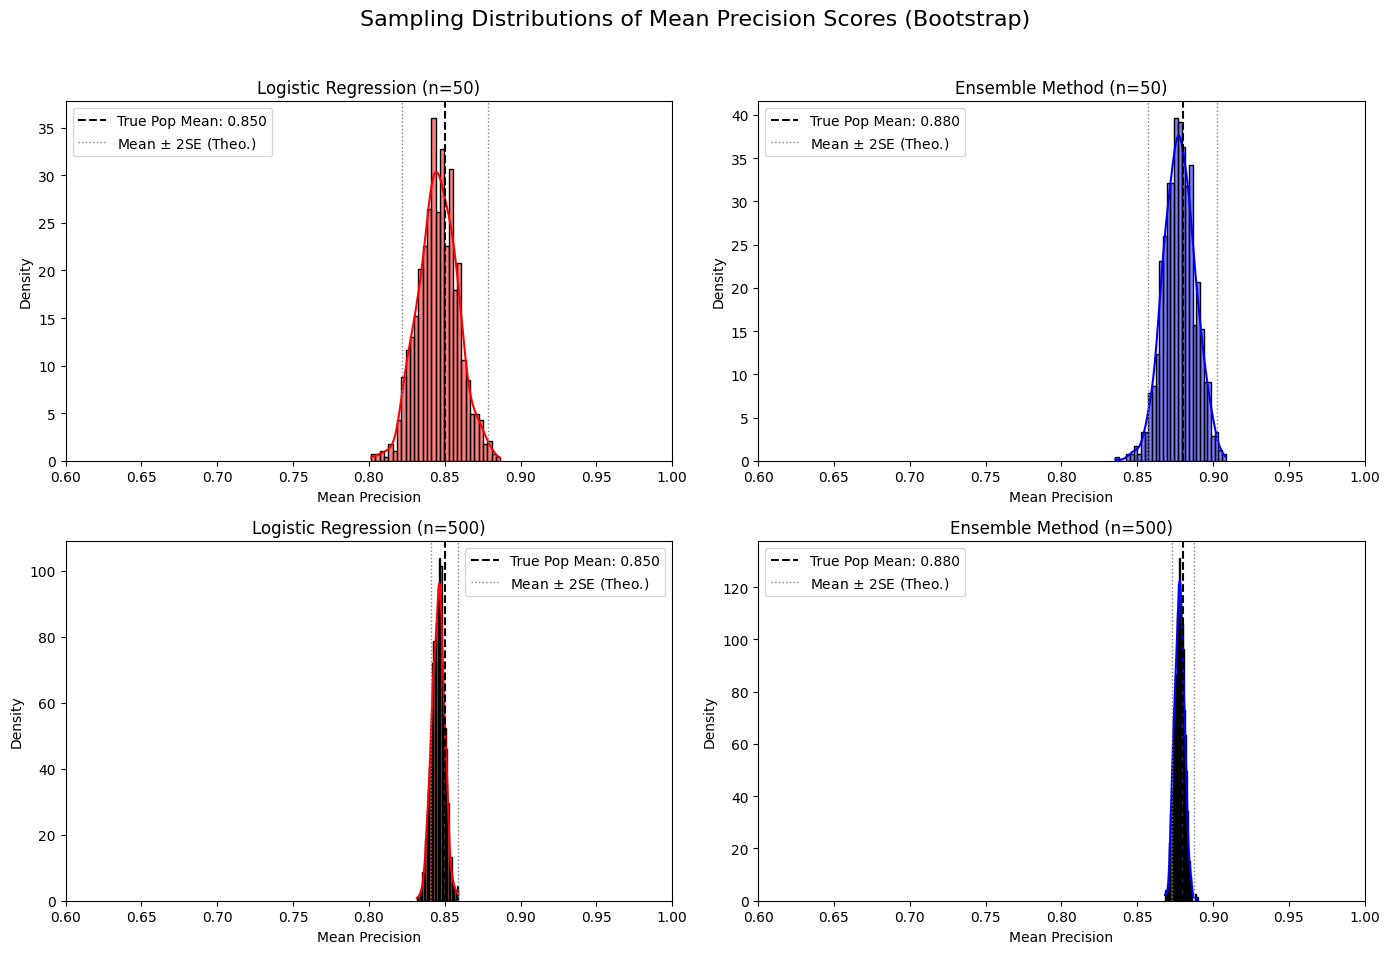

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Define Model Parameters ---
# Logistic Model (baseline)
mean_logistic_pop = 0.85
std_logistic_pop = 0.10

# Ensemble Model (sophisticated)
mean_ensemble_pop = 0.88
std_ensemble_pop = 0.08

# Population size for true distributions
population_size = 10000

# Sample sizes for bootstrap simulations
n_small = 50   # Small validation set
n_large = 500  # Realistic production scale validation set
n_bootstrap = 1000 # Number of bootstrap resamples

# --- 2. Calculate Lognormal Parameters (mu_log, sigma_log) ---
# For a lognormal distribution with given mean (m) and std dev (s):
# mu_log = ln(m^2 / sqrt(s^2 + m^2))
# sigma_log = sqrt(ln(1 + s^2 / m^2))

def get_lognormal_params(mean_val, std_val):
    var_val = std_val**2
    mu_log = np.log(mean_val**2 / np.sqrt(var_val + mean_val**2))
    sigma_log = np.sqrt(np.log(1 + var_val / mean_val**2))
    return mu_log, sigma_log

mu_log_logistic, sigma_log_logistic = get_lognormal_params(mean_logistic_pop, std_logistic_pop)
mu_log_ensemble, sigma_log_ensemble = get_lognormal_params(mean_ensemble_pop, std_ensemble_pop)

print(f"Lognormal parameters for Logistic Model: mu_log={mu_log_logistic:.3f}, sigma_log={sigma_log_logistic:.3f}")
print(f"Lognormal parameters for Ensemble Model: mu_log={mu_log_ensemble:.3f}, sigma_log={sigma_log_ensemble:.3f}")

# --- 3. Generate Lognormal Populations ---
np.random.seed(42) # for reproducibility

pop_logistic = np.random.lognormal(mean=mu_log_logistic, sigma=sigma_log_logistic, size=population_size)
pop_ensemble = np.random.lognormal(mean=mu_log_ensemble, sigma=sigma_log_ensemble, size=population_size)

# Clip precision values to be between 0 and 1, as precision scores cannot exceed 1
pop_logistic = np.clip(pop_logistic, 0, 1)
pop_ensemble = np.clip(pop_ensemble, 0, 1)

print(f"\nGenerated Logistic Population Mean: {np.mean(pop_logistic):.3f}, Std: {np.std(pop_logistic):.3f}")
print(f"Generated Ensemble Population Mean: {np.mean(pop_ensemble):.3f}, Std: {np.std(pop_ensemble):.3f}")

# --- 4. Perform Bootstrap Resampling and Collect Means ---
bootstrap_means = {
    'logistic_small_n': [],
    'logistic_large_n': [],
    'ensemble_small_n': [],
    'ensemble_large_n': []
}

for _ in range(n_bootstrap):
    # Logistic Model, small n
    sample = np.random.choice(pop_logistic, size=n_small, replace=True)
    bootstrap_means['logistic_small_n'].append(np.mean(sample))

    # Logistic Model, large n
    sample = np.random.choice(pop_logistic, size=n_large, replace=True)
    bootstrap_means['logistic_large_n'].append(np.mean(sample))

    # Ensemble Model, small n
    sample = np.random.choice(pop_ensemble, size=n_small, replace=True)
    bootstrap_means['ensemble_small_n'].append(np.mean(sample))

    # Ensemble Model, large n
    sample = np.random.choice(pop_ensemble, size=n_large, replace=True)
    bootstrap_means['ensemble_large_n'].append(np.mean(sample))

# Convert lists to numpy arrays for easier calculations
for key in bootstrap_means:
    bootstrap_means[key] = np.array(bootstrap_means[key])

# --- 5. Calculate Empirical SE for small n ---
emp_se_logistic_small = np.std(bootstrap_means['logistic_small_n'])
emp_se_ensemble_small = np.std(bootstrap_means['ensemble_small_n'])

print(f"\nEmpirical Standard Error (Logistic, n={n_small}): {emp_se_logistic_small:.4f}")
print(f"Empirical Standard Error (Ensemble, n={n_small}): {emp_se_ensemble_small:.4f}")

# --- 6. Plot Sampling Distributions ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Sampling Distributions of Mean Precision Scores (Bootstrap)', fontsize=16)

plot_data = [
    (bootstrap_means['logistic_small_n'], f'Logistic Regression (n={n_small})', mean_logistic_pop, std_logistic_pop, n_small, axes[0, 0], 'red'),
    (bootstrap_means['ensemble_small_n'], f'Ensemble Method (n={n_small})', mean_ensemble_pop, std_ensemble_pop, n_small, axes[0, 1], 'blue'),
    (bootstrap_means['logistic_large_n'], f'Logistic Regression (n={n_large})', mean_logistic_pop, std_logistic_pop, n_large, axes[1, 0], 'red'),
    (bootstrap_means['ensemble_large_n'], f'Ensemble Method (n={n_large})', mean_ensemble_pop, std_ensemble_pop, n_large, axes[1, 1], 'blue')
]

for means, title, pop_mean, pop_std, current_n, ax, color in plot_data:
    sns.histplot(means, bins=30, kde=True, ax=ax, color=color, stat='density')
    ax.axvline(pop_mean, color='black', linestyle='dashed', linewidth=1.5, label=f'True Pop Mean: {pop_mean:.3f}')

    # Theoretical SE for comparison (using population std, not sample std)
    theoretical_se = pop_std / np.sqrt(current_n)
    ax.axvline(pop_mean - 2 * theoretical_se, color='gray', linestyle='dotted', linewidth=1, label=r'Mean $\pm$ 2SE (Theo.)')
    ax.axvline(pop_mean + 2 * theoretical_se, color='gray', linestyle='dotted', linewidth=1)

    ax.set_title(title)
    ax.set_xlabel('Mean Precision')
    ax.set_ylabel('Density')
    ax.legend()
    ax.set_xlim(0.6, 1.0) # Set consistent x-axis limits for better comparison

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

### Explanation of Sampling Variability in AI Metrics

This simulation illustrates how sample size significantly impacts the perceived performance of AI models, particularly in contexts like imbalanced data where precision is a key metric.

**1. Simulation Results Overview:**
*   The plots display the sampling distributions of mean precision scores for two AI models (Logistic Regression and Ensemble Method) across different validation set sizes (n=50 and n=500).
*   For `n=50` (top row), the distributions are wider and overlap significantly, suggesting that a model with a lower true population precision (Logistic, 0.85) could easily appear to outperform a superior model (Ensemble, 0.88) by chance in a small sample.
*   For `n=500` (bottom row), the distributions are much narrower and more distinctly separated, with their peaks closer to their respective true population means. This indicates that larger sample sizes provide more reliable estimates of true model performance.

**2. Central Limit Theorem (CLT) and Distribution Shapes:**
*   The **Central Limit Theorem** predicts that the sampling distribution of sample means (or in this case, mean precision scores from bootstrapped samples) will be approximately normal, regardless of the underlying population distribution, as the sample size (`n`) increases. This is evident in the plots:
    *   Even though our underlying precision scores follow a lognormal (skewed) distribution, the distributions of the *mean* precision scores for both models become more bell-shaped as `n` increases from 50 to 500.
    *   The **spread** of these sampling distributions is quantified by the **Standard Error (SE)**, which is $SE = \sigma / \sqrt{n}$. As `n` increases, $SE$ decreases, meaning the sample means cluster more tightly around the true population mean. This is clearly visible; the histograms for `n=500` are much narrower than those for `n=50`.

**3. Why Extreme Rankings Emerge at Low n:**
*   **Higher Variability:** With a small sample size ($n=50$), the standard error is relatively large (as seen in the empirical SE values calculated: Logistic $\approx 0.013$, Ensemble $\approx 0.011$). This large variability means that a single validation run can easily yield a sample mean precision that deviates substantially from the true population precision.
*   **Chance Outperformance:** Because the distributions for `n=50` are wide and overlap, it is highly probable that the Logistic Regression model (with a true mean of 0.85) could, by random chance, achieve a mean precision of, say, 0.90 in a specific validation run, while the Ensemble model (with a true mean of 0.88) might get 0.60. This is the exact scenario described in the problem statement.
*   This phenomenon is a direct consequence of the larger sampling error inherent in small samples. The perceived ranking on a small validation set can be heavily influenced by random chance, making it an unreliable indicator of true production performance.

**4. Impact on AI Decisions:**
*   **Erroneous Model Selection:** Basing model selection on small validation sets can lead to choosing a sub-optimal model (e.g., picking the simpler Logistic Regression over the more powerful Ensemble) simply due to sampling variability. This can result in deploying models that underperform in production, leading to missed fraud detection, inefficient resource allocation, or poor user experience.
*   **Misleading Performance Reporting:** Reporting metrics from small validation sets can give a false sense of a model's stability or effectiveness, potentially leading to incorrect business decisions or misallocation of development efforts.
*   **Lack of Trust:** Inconsistent performance between validation and production environments erodes trust in AI systems and the data science team.

**5. Proposed Mitigation for Imbalanced Data:**
To prevent errant decisions due to sampling variability and imbalanced data when evaluating AI models:

*   **Increase Validation Set Size:** Whenever possible, use larger validation sets ($n$ values like 500 or more, as simulated) to reduce the standard error and obtain more reliable estimates of model performance. This aligns with the CLT, showing that larger $n$ leads to narrower sampling distributions.
*   **Stratified Sampling:** Ensure that the validation set maintains the same proportion of minority (fraudulent) and majority classes as the overall dataset. This prevents a small validation set from, by chance, having an unrepresentative number of fraud cases, which can dramatically skew precision scores.
*   **Cross-Validation:** Employ robust evaluation techniques like K-Fold Cross-Validation. This involves splitting the data into multiple folds, training and validating the model multiple times, and averaging the performance metrics. This provides a more stable estimate of performance by reducing the impact of any single random split.
*   **Bootstrap Resampling (as simulated):** Use bootstrapping to generate many validation samples and observe the distribution of performance metrics. This helps to understand the uncertainty and variability of the chosen metric, rather than relying on a single point estimate.
*   **Focus on Relevant Metrics:** For imbalanced datasets, precision is crucial, but also consider metrics like Recall, F1-score, Area Under the Receiver Operating Characteristic Curve (AUROC), and Area Under the Precision-Recall Curve (AUPRC). AUPRC is particularly informative for highly imbalanced datasets.
*   **Confidence Intervals:** Instead of just reporting point estimates of precision, provide confidence intervals for these metrics. This explicitly communicates the uncertainty associated with the estimate due to finite sample sizes. For example, instead of saying "precision is 0.90", say "precision is 0.90 (95% CI: 0.85 - 0.95)".
*   **Domain Expertise Integration:** Work closely with domain experts to understand the cost of false positives and false negatives, and align model evaluation with real-world business impact.